
# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

**Name:** SNEHA VARGHESE  
**Reg No:** 2547250 
**Course:** MCA – IV Trimester  
**Subject:** Machine Learning Lab  

---

## Aim
1. To understand how to implement neural networks using Keras and TensorFlow.
2. To solve the non-linear XOR problem using an MLP and study the effect of
   hyperparameters such as learning rate, activation functions, number of neurons,
   and epochs on model performance.

## The XOR Truth Table

| Input 1 | Input 2 | XOR Output |
|---------|---------|------------|
|    0    |    0    |     0      |
|    0    |    1    |     1      |
|    1    |    0    |     1      |
|    1    |    1    |     0      |

> **Why XOR is Non-Linear?**  
> XOR cannot be separated by a single straight line (it is **not linearly separable**).
> A single-layer perceptron fails to learn XOR. An MLP with at least one hidden layer
> can solve it by learning non-linear decision boundaries.

---
## Setup: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported successfully!')

---
## Step 1: Create the XOR Dataset

In [ ]:
# XOR input combinations (all 4 possible binary inputs)
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

# XOR ground truth outputs
y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

print('=' * 45)
print('         XOR Dataset')
print('=' * 45)
print(f'{"Input 1":^10} {"Input 2":^10} {"XOR Output":^12}')
print('-' * 45)
for i in range(len(X)):
    print(f'{int(X[i][0]):^10} {int(X[i][1]):^10} {int(y[i][0]):^12}')
print('=' * 45)
print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')

         XOR Dataset
 Input 1    Input 2    XOR Output 
---------------------------------------------
    0          0           0      
    0          1           1      
    1          0           1      
    1          1           0      

X shape: (4, 2)
y shape: (4, 1)


---
## Implementation 1: Keras (TensorFlow High-Level API)

Keras provides a simple, user-friendly API for building neural networks.
We use `Sequential` to stack layers declaratively.

### Step 2: Build the MLP Model (Keras)

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

# Architecture:
#   Input  : 2 neurons  (one per XOR input)
#   Hidden : 4 neurons  (tanh activation)
#   Output : 1 neuron   (sigmoid for binary classification)
keras_model = Sequential([
    Dense(4, input_shape=(2,), activation='tanh', name='hidden_layer'),
    Dense(1, activation='sigmoid', name='output_layer')
], name='XOR_Keras_MLP')

keras_model.summary()

Model: "XOR_Keras_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

### Step 3: Compile the Model (Keras)

In [ ]:
keras_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully!')
print('Optimizer : Adam (learning rate = 0.01)')
print('Loss      : Binary Cross-Entropy')
print('Metrics   : Accuracy')

Model compiled successfully!
Optimizer : Adam (learning rate = 0.01)
Loss      : Binary Cross-Entropy
Metrics   : Accuracy


### Step 4: Train the Model (Keras)

In [ ]:
keras_history = keras_model.fit(
    X, y,
    epochs=5000,
    verbose=0,      # Suppress per-epoch output
    batch_size=4    # Full-batch (all 4 XOR samples)
)

print('Training complete!')
print(f"Final Loss     : {keras_history.history['loss'][-1]:.6f}")
print(f"Final Accuracy : {keras_history.history['accuracy'][-1] * 100:.2f}%")

Training complete!
Final Loss     : 0.000186
Final Accuracy : 100.00%


### Step 5: Evaluate & Predict (Keras)

In [ ]:
keras_pred_probs  = keras_model.predict(X, verbose=0)
keras_pred_labels = (keras_pred_probs >= 0.5).astype(int)

print('=' * 60)
print('    Keras Model – Prediction Results')
print('=' * 60)
print(f'{"Input":^12} {"True":^8} {"Predicted Prob":^16} {"Predicted":^10} {"Correct?":^10}')
print('-' * 60)
all_correct_keras = True
for i in range(len(X)):
    inp   = f'({int(X[i][0])}, {int(X[i][1])})'
    true_v = int(y[i][0])
    prob   = keras_pred_probs[i][0]
    pred   = keras_pred_labels[i][0]
    ok     = 'Yes' if pred == true_v else 'No'
    if pred != true_v: all_correct_keras = False
    print(f'{inp:^12} {true_v:^8} {prob:^16.4f} {pred:^10} {ok:^10}')
print('=' * 60)
status = 'Keras model learned XOR correctly!' if all_correct_keras else 'Keras model did NOT learn XOR correctly. Try more epochs.'
print(status)

    Keras Model – Prediction Results
   Input       True    Predicted Prob  Predicted   Correct? 
------------------------------------------------------------
   (0, 0)       0          0.0001          0         Yes    
   (0, 1)       1          0.9997          1         Yes    
   (1, 0)       1          1.0000          1         Yes    
   (1, 1)       0          0.0003          0         Yes    
Keras model learned XOR correctly!


### Training Curve (Keras)

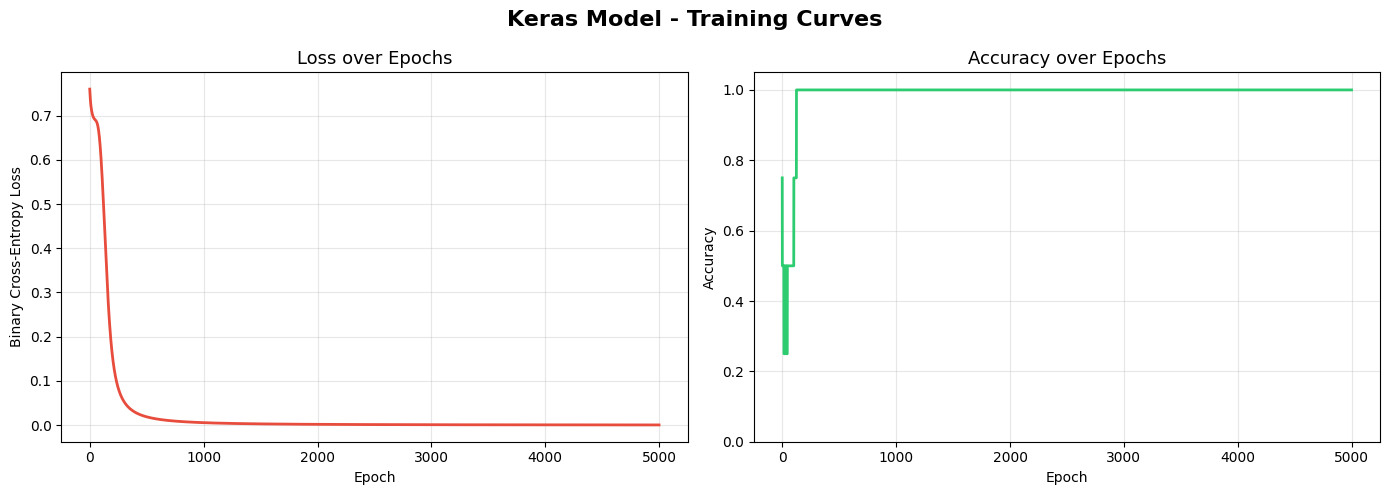

Saved: keras_training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Keras Model - Training Curves', fontsize=16, fontweight='bold')

axes[0].plot(keras_history.history['loss'], color='#E74C3C', linewidth=2)
axes[0].set_title('Loss over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(keras_history.history['accuracy'], color='#2ECC71', linewidth=2)
axes[1].set_title('Accuracy over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('keras_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: keras_training_curves.png")

### Decision Boundary (Keras)

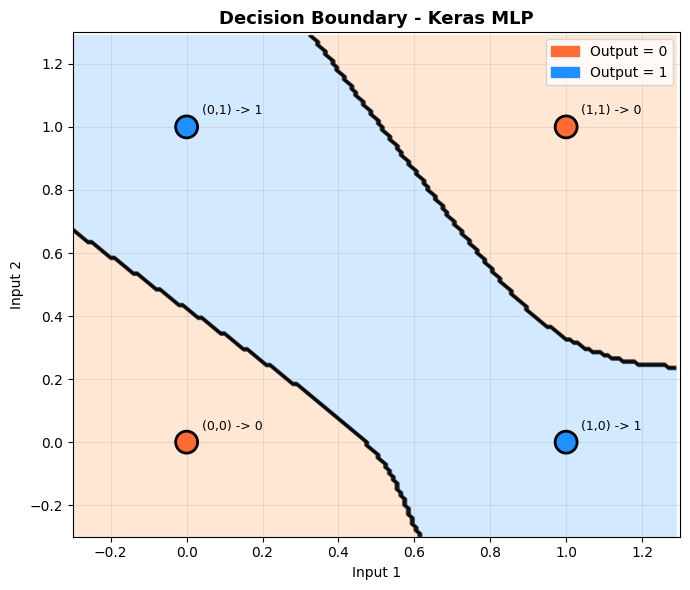

Saved: keras_decision_boundary.png


In [ ]:
def plot_decision_boundary(model, X, y, title, predict_fn=None, ax=None):
    """Plots the decision boundary for a binary XOR classifier."""
    h = 0.01
    x_min, x_max = -0.3, 1.3
    y_min, y_max = -0.3, 1.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    if predict_fn:
        Z = predict_fn(grid)
    else:
        Z = model.predict(grid, verbose=0).ravel()

    Z = (Z >= 0.5).astype(int).reshape(xx.shape)
    cmap_bg = ListedColormap(['#FFDDC1', '#C1E1FF'])

    if ax is None:
        fig_local, ax = plt.subplots(figsize=(7, 6))

    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.7)
    ax.contour(xx, yy, Z, colors='black', linewidths=1.5, alpha=0.5)

    colors_pt = ['#FF6B35' if lbl == 0 else '#1E90FF' for lbl in y.ravel()]
    ax.scatter(X[:, 0], X[:, 1], c=colors_pt, edgecolors='black',
               s=250, zorder=5, linewidths=2)

    for i, (xi, yi) in enumerate(zip(X, y.ravel())):
        ax.annotate(f'({int(xi[0])},{int(xi[1])}) -> {int(yi)}',
                    xy=(xi[0], xi[1]), xytext=(xi[0]+0.04, xi[1]+0.04),
                    fontsize=9)

    patch0 = mpatches.Patch(color='#FF6B35', label='Output = 0')
    patch1 = mpatches.Patch(color='#1E90FF', label='Output = 1')
    ax.legend(handles=[patch0, patch1], loc='upper right', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Input 1')
    ax.set_ylabel('Input 2')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)
    return ax


fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_boundary(keras_model, X, y, 'Decision Boundary - Keras MLP', ax=ax)
plt.tight_layout()
plt.savefig('keras_decision_boundary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: keras_decision_boundary.png')

---
## Implementation 2: TensorFlow Low-Level API

The TensorFlow low-level API gives us complete control over the computation graph,
variables, gradient computation, and weight updates using `tf.Variable` and `tf.GradientTape`.

### Step 2: Define Network Variables (TensorFlow Low-Level)

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

# Architecture:
#   Input  : 2 neurons
#   Hidden : 4 neurons  (tanh activation)
#   Output : 1 neuron   (sigmoid activation)

n_input  = 2
n_hidden = 4
n_output = 1

# Hidden layer weights and biases
W1 = tf.Variable(tf.random.normal([n_input, n_hidden], stddev=0.5), name='W1')
b1 = tf.Variable(tf.zeros([n_hidden]), name='b1')

# Output layer weights and biases
W2 = tf.Variable(tf.random.normal([n_hidden, n_output], stddev=0.5), name='W2')
b2 = tf.Variable(tf.zeros([n_output]), name='b2')

trainable_vars = [W1, b1, W2, b2]

print('TensorFlow Low-Level Variables Initialized:')
print(f'  W1 shape : {W1.shape}  (Input to Hidden)')
print(f'  b1 shape : {b1.shape}  (Hidden bias)')
print(f'  W2 shape : {W2.shape}  (Hidden to Output)')
print(f'  b2 shape : {b2.shape}  (Output bias)')

TensorFlow Low-Level Variables Initialized:
  W1 shape : (2, 4)  (Input to Hidden)
  b1 shape : (4,)  (Hidden bias)
  W2 shape : (4, 1)  (Hidden to Output)
  b2 shape : (1,)  (Output bias)


### Step 3: Define Forward Pass, Loss & Optimizer (TF Low-Level)

In [ ]:
def forward_pass(X_input):
    """Performs a forward pass through the 2-layer MLP."""
    # Hidden layer: linear transformation + tanh activation
    z1 = tf.matmul(X_input, W1) + b1
    a1 = tf.nn.tanh(z1)

    # Output layer: linear transformation + sigmoid activation
    z2 = tf.matmul(a1, W2) + b2
    a2 = tf.nn.sigmoid(z2)
    return a2


def binary_cross_entropy_loss(y_true, y_pred):
    """Computes Binary Cross-Entropy loss manually."""
    # Clip predictions to avoid log(0)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    loss = -tf.reduce_mean(
        y_true * tf.math.log(y_pred) +
        (1 - y_true) * tf.math.log(1 - y_pred)
    )
    return loss


# Optimizer (same as Keras implementation)
tf_optimizer = Adam(learning_rate=0.01)

print('Forward pass function   : defined')
print('Loss function           : Binary Cross-Entropy (manual implementation)')
print('Optimizer               : Adam (lr=0.01)')

Forward pass function   : defined
Loss function           : Binary Cross-Entropy (manual implementation)
Optimizer               : Adam (lr=0.01)


### Step 4: Training Loop with GradientTape (TF Low-Level)

In [ ]:
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

EPOCHS = 5000
tf_losses      = []
tf_accuracies  = []

for epoch in range(EPOCHS):
    # GradientTape records all operations for automatic differentiation
    with tf.GradientTape() as tape:
        predictions = forward_pass(X_tf)
        loss = binary_cross_entropy_loss(y_tf, predictions)

    # Compute gradients with respect to all trainable variables
    gradients = tape.gradient(loss, trainable_vars)

    # Apply gradients (weight update)
    tf_optimizer.apply_gradients(zip(gradients, trainable_vars))

    # Track metrics
    tf_losses.append(loss.numpy())
    pred_labels = tf.cast(predictions >= 0.5, tf.float32)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(pred_labels, y_tf), tf.float32)).numpy()
    tf_accuracies.append(accuracy)

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch+1:5d}/{EPOCHS} | Loss: {loss.numpy():.6f} | Accuracy: {accuracy*100:.2f}%')

print('\nTraining complete!')
print(f'Final Loss     : {tf_losses[-1]:.6f}')
print(f'Final Accuracy : {tf_accuracies[-1] * 100:.2f}%')

Epoch  1000/5000 | Loss: 0.006021 | Accuracy: 100.00%
Epoch  2000/5000 | Loss: 0.001782 | Accuracy: 100.00%
Epoch  3000/5000 | Loss: 0.000791 | Accuracy: 100.00%
Epoch  4000/5000 | Loss: 0.000408 | Accuracy: 100.00%
Epoch  5000/5000 | Loss: 0.000226 | Accuracy: 100.00%

Training complete!
Final Loss     : 0.000226
Final Accuracy : 100.00%


### Step 5: Evaluate & Predict (TF Low-Level)

In [ ]:
tf_pred_probs  = forward_pass(X_tf).numpy()
tf_pred_labels = (tf_pred_probs >= 0.5).astype(int)

print('=' * 70)
print('    TensorFlow Low-Level Model - Prediction Results')
print('=' * 70)
print(f'{"Input":^12} {"True":^8} {"Predicted Prob":^16} {"Predicted":^10} {"Correct?":^10}')
print('-' * 70)
all_correct_tf = True
for i in range(len(X)):
    inp    = f'({int(X[i][0])}, {int(X[i][1])})'
    true_v = int(y[i][0])
    prob   = tf_pred_probs[i][0]
    pred   = tf_pred_labels[i][0]
    ok     = 'Yes' if pred == true_v else 'No'
    if pred != true_v: all_correct_tf = False
    print(f'{inp:^12} {true_v:^8} {prob:^16.4f} {pred:^10} {ok:^10}')
print('=' * 70)
status = 'TF Low-Level model learned XOR correctly!' if all_correct_tf else 'TF Low-Level model did NOT learn XOR correctly.'
print(status)

    TensorFlow Low-Level Model - Prediction Results
   Input       True    Predicted Prob  Predicted   Correct? 
----------------------------------------------------------------------
   (0, 0)       0          0.0000          0         Yes    
   (0, 1)       1          0.9996          1         Yes    
   (1, 0)       1          0.9999          1         Yes    
   (1, 1)       0          0.0004          0         Yes    
TF Low-Level model learned XOR correctly!


### Training Curve (TF Low-Level)

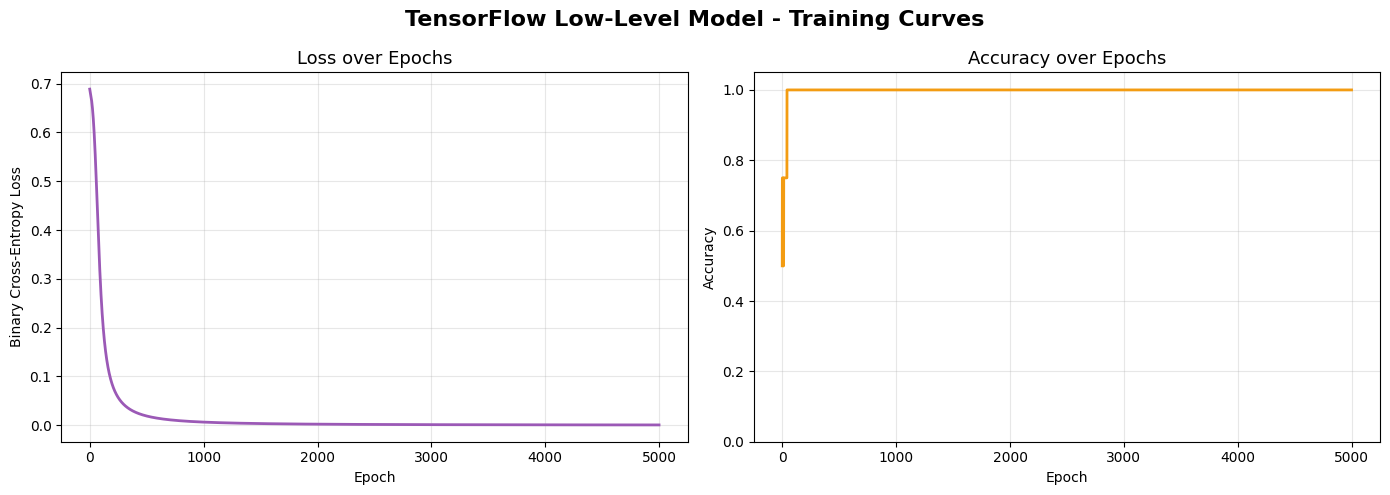

Saved: tf_training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TensorFlow Low-Level Model - Training Curves', fontsize=16, fontweight='bold')

axes[0].plot(tf_losses, color='#9B59B6', linewidth=2)
axes[0].set_title('Loss over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tf_accuracies, color='#F39C12', linewidth=2)
axes[1].set_title('Accuracy over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tf_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: tf_training_curves.png')

### Decision Boundary (TF Low-Level)

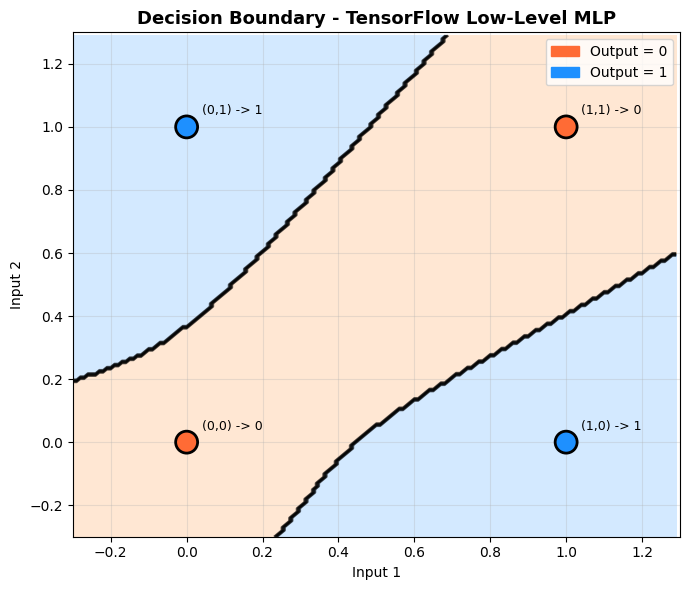

Saved: tf_decision_boundary.png


In [ ]:
def tf_predict_fn(grid_input):
    """Wrapper to run TF low-level model on a mesh grid."""
    grid_tensor = tf.constant(grid_input, dtype=tf.float32)
    return forward_pass(grid_tensor).numpy().ravel()


fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_boundary(None, X, y,
                       'Decision Boundary - TensorFlow Low-Level MLP',
                       predict_fn=tf_predict_fn, ax=ax)
plt.tight_layout()
plt.savefig('tf_decision_boundary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: tf_decision_boundary.png')

---
## Optional Exercise A: Side-by-Side Training Curve Comparison

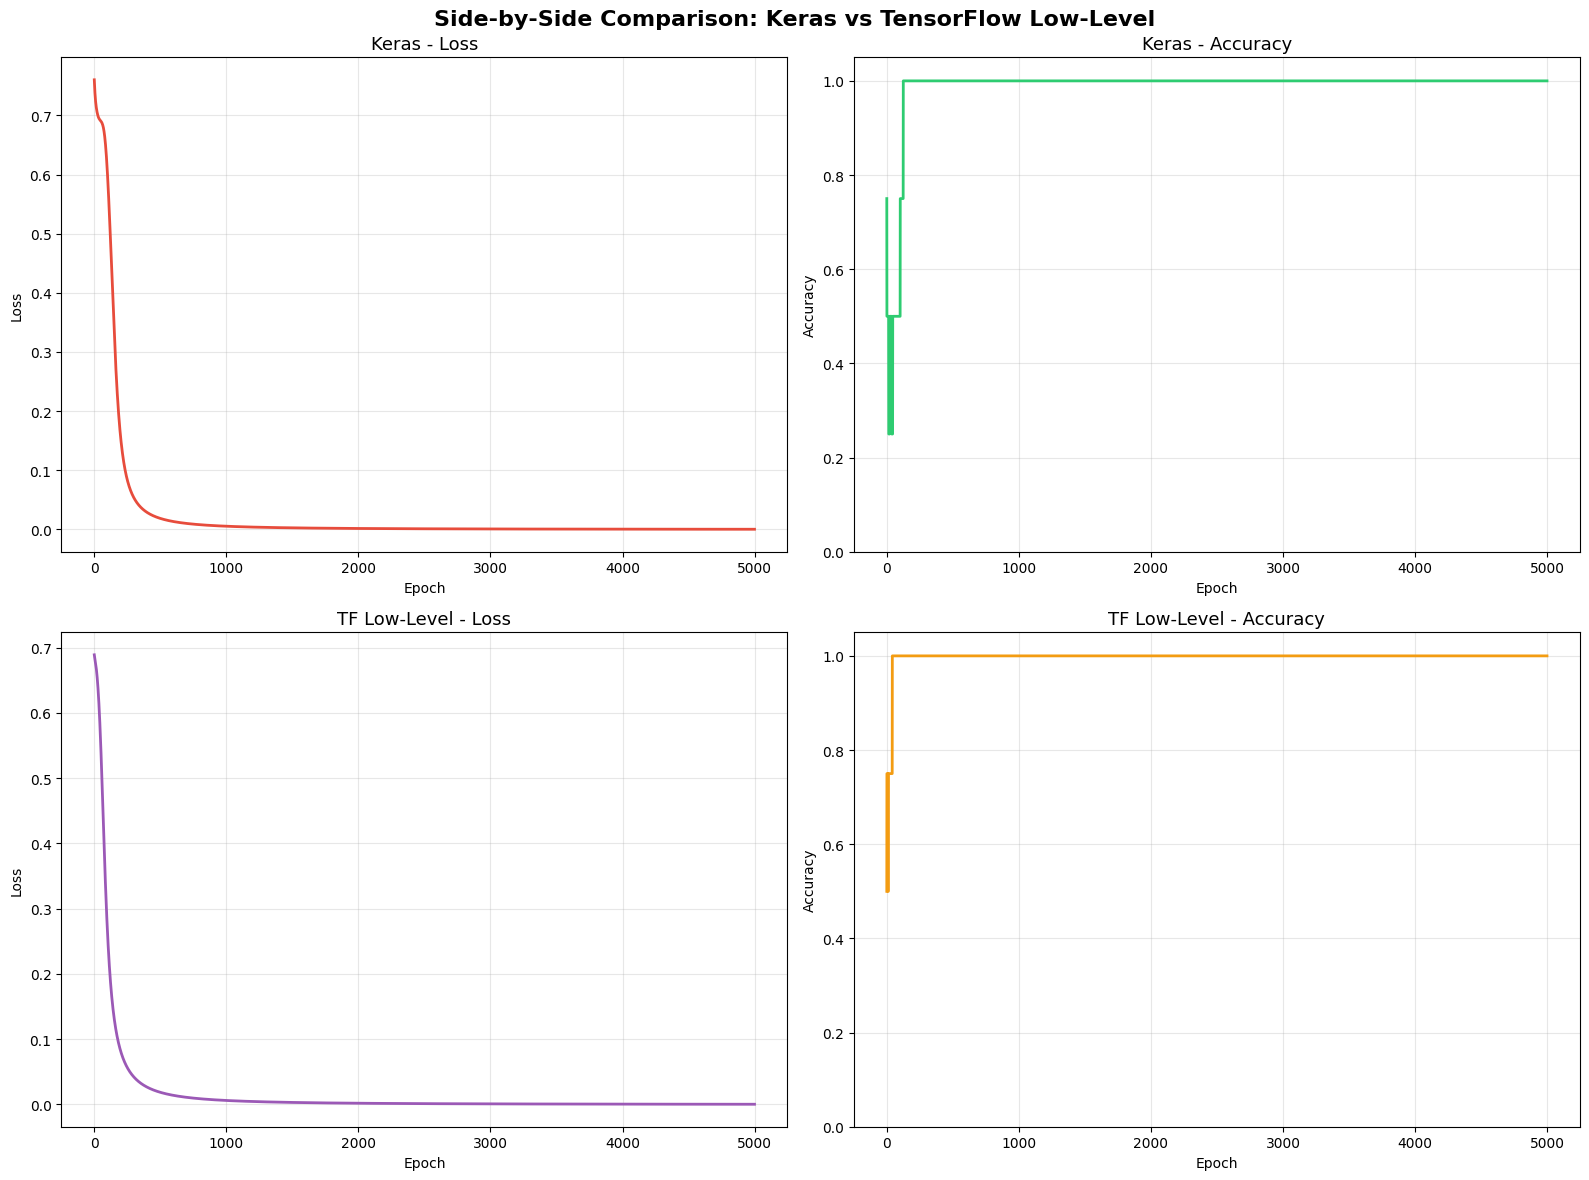

Saved: comparison_training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Side-by-Side Comparison: Keras vs TensorFlow Low-Level', fontsize=16, fontweight='bold')

# Row 0: Keras
axes[0][0].plot(keras_history.history['loss'], color='#E74C3C', linewidth=2)
axes[0][0].set_title('Keras - Loss', fontsize=13)
axes[0][0].set_xlabel('Epoch'); axes[0][0].set_ylabel('Loss')
axes[0][0].grid(True, alpha=0.3)

axes[0][1].plot(keras_history.history['accuracy'], color='#2ECC71', linewidth=2)
axes[0][1].set_title('Keras - Accuracy', fontsize=13)
axes[0][1].set_xlabel('Epoch'); axes[0][1].set_ylabel('Accuracy')
axes[0][1].set_ylim([0, 1.05]); axes[0][1].grid(True, alpha=0.3)

# Row 1: TF Low-Level
axes[1][0].plot(tf_losses, color='#9B59B6', linewidth=2)
axes[1][0].set_title('TF Low-Level - Loss', fontsize=13)
axes[1][0].set_xlabel('Epoch'); axes[1][0].set_ylabel('Loss')
axes[1][0].grid(True, alpha=0.3)

axes[1][1].plot(tf_accuracies, color='#F39C12', linewidth=2)
axes[1][1].set_title('TF Low-Level - Accuracy', fontsize=13)
axes[1][1].set_xlabel('Epoch'); axes[1][1].set_ylabel('Accuracy')
axes[1][1].set_ylim([0, 1.05]); axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: comparison_training_curves.png')

### Decision Boundaries Side-by-Side

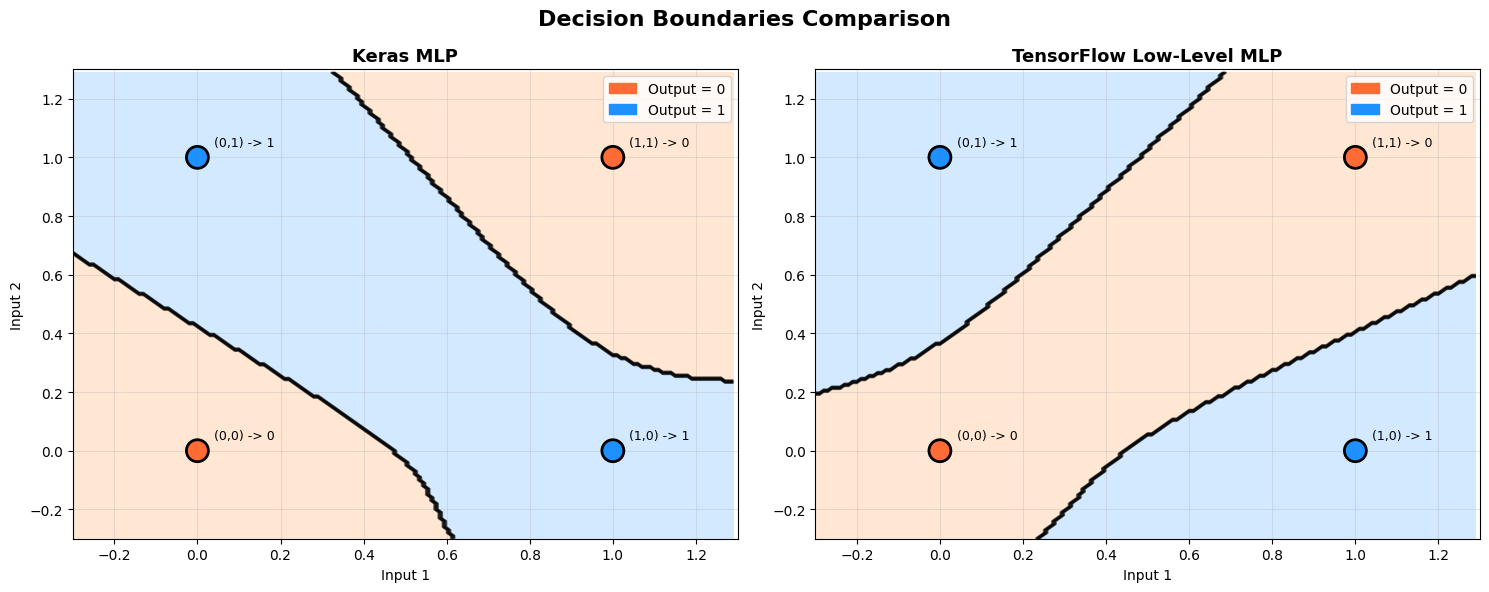

Saved: comparison_decision_boundaries.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Decision Boundaries Comparison', fontsize=16, fontweight='bold')

plot_decision_boundary(keras_model, X, y, 'Keras MLP', ax=ax1)
plot_decision_boundary(None, X, y, 'TensorFlow Low-Level MLP',
                       predict_fn=tf_predict_fn, ax=ax2)

plt.tight_layout()
plt.savefig('comparison_decision_boundaries.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: comparison_decision_boundaries.png')

---
## Optional Exercise B: Hyperparameter Analysis

### B1: Effect of Learning Rate

LR = 0.001  ->  Final Accuracy: 100.00%
LR = 0.010  ->  Final Accuracy: 100.00%
LR = 0.050  ->  Final Accuracy: 100.00%
LR = 0.100  ->  Final Accuracy: 100.00%


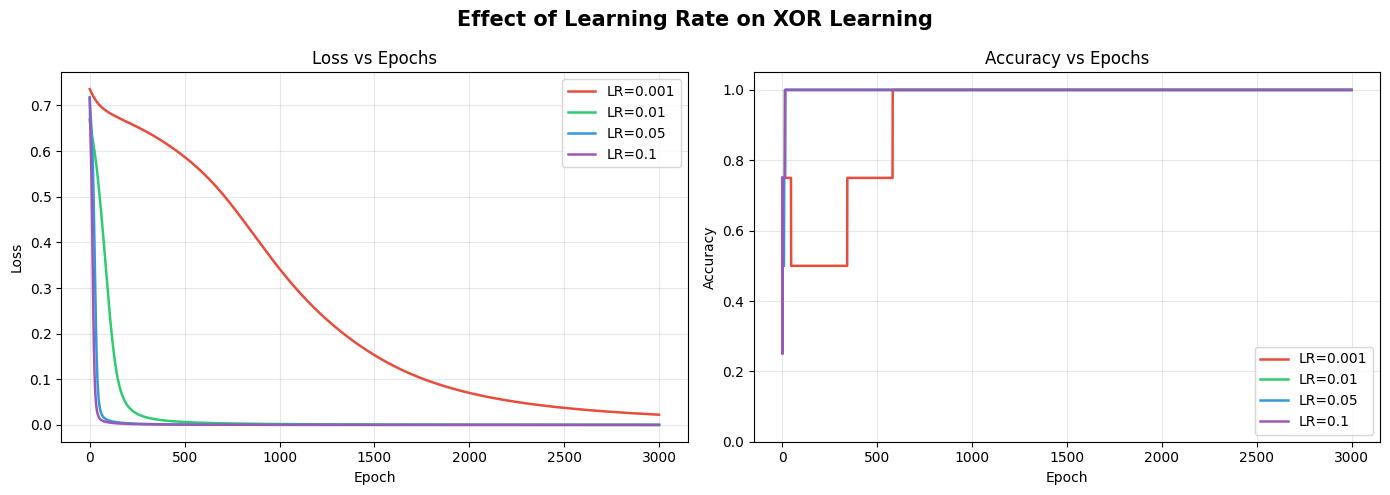

In [ ]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
lr_results = {}

for lr in learning_rates:
    tf.random.set_seed(42)
    m = Sequential([
        Dense(4, input_shape=(2,), activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=lr),
              loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X, y, epochs=3000, verbose=0, batch_size=4)
    lr_results[lr] = h.history
    print(f'LR = {lr:.3f}  ->  Final Accuracy: {h.history["accuracy"][-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Learning Rate on XOR Learning', fontsize=15, fontweight='bold')
colors_lr = ['#E74C3C', '#2ECC71', '#3498DB', '#9B59B6']
for (lr, hist), color in zip(lr_results.items(), colors_lr):
    axes[0].plot(hist['loss'],     label=f'LR={lr}', color=color, linewidth=1.8)
    axes[1].plot(hist['accuracy'], label=f'LR={lr}', color=color, linewidth=1.8)
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set(title='Loss vs Epochs',     xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Accuracy vs Epochs', xlabel='Epoch', ylabel='Accuracy')
axes[1].set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('lr_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### B2: Effect of Activation Function

Activation = tanh     -> Final Accuracy: 100.00%
Activation = relu     -> Final Accuracy: 75.00%
Activation = sigmoid  -> Final Accuracy: 100.00%


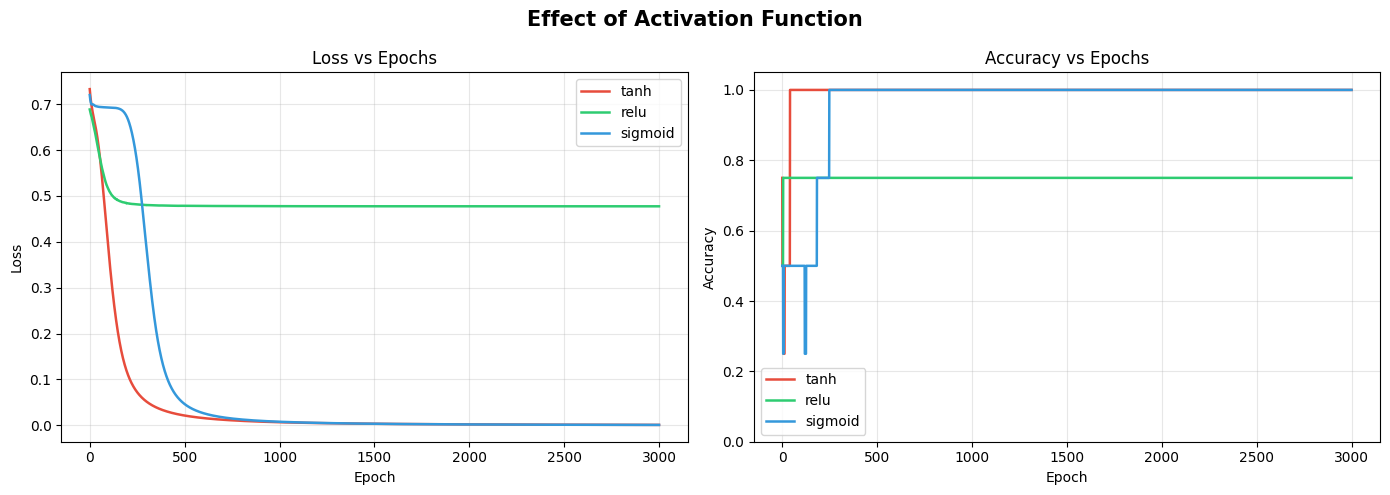

In [ ]:
activations = ['tanh', 'relu', 'sigmoid']
act_results = {}

for act in activations:
    tf.random.set_seed(42)
    m = Sequential([
        Dense(4, input_shape=(2,), activation=act),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X, y, epochs=3000, verbose=0, batch_size=4)
    act_results[act] = h.history
    print(f'Activation = {act:8s} -> Final Accuracy: {h.history["accuracy"][-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Activation Function', fontsize=15, fontweight='bold')
colors_act = ['#E74C3C', '#2ECC71', '#3498DB']
for (act, hist), color in zip(act_results.items(), colors_act):
    axes[0].plot(hist['loss'],     label=act, color=color, linewidth=1.8)
    axes[1].plot(hist['accuracy'], label=act, color=color, linewidth=1.8)
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set(title='Loss vs Epochs',     xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Accuracy vs Epochs', xlabel='Epoch', ylabel='Accuracy')
axes[1].set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('activation_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### B3: Effect of Number of Hidden Neurons

Neurons =  2 -> Final Accuracy: 100.00%
Neurons =  4 -> Final Accuracy: 100.00%
Neurons =  8 -> Final Accuracy: 100.00%
Neurons = 16 -> Final Accuracy: 100.00%


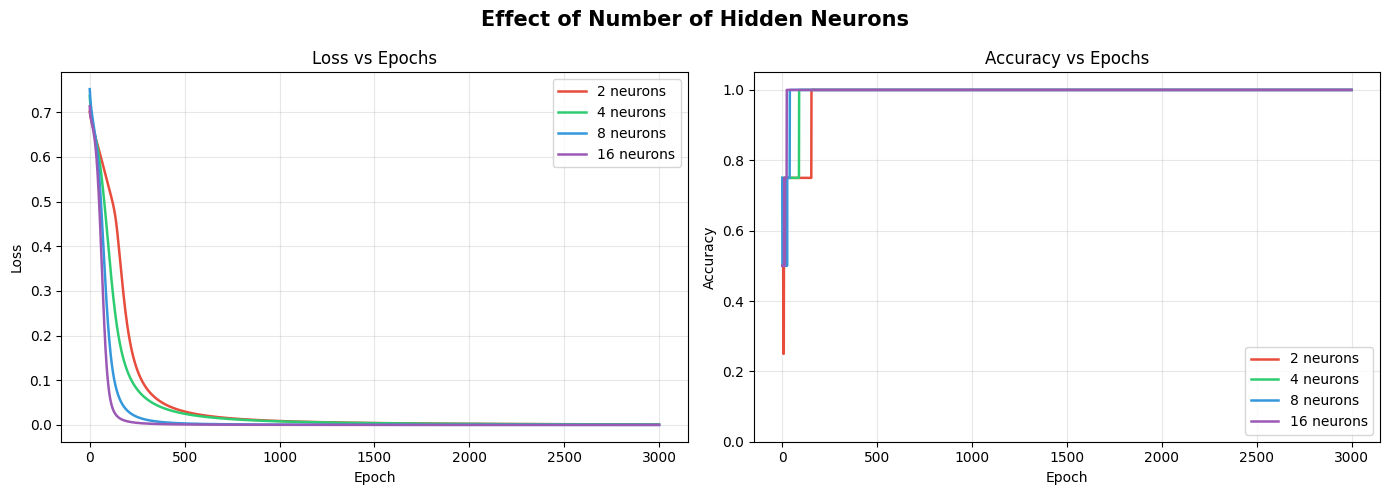

In [ ]:
neuron_counts = [2, 4, 8, 16]
neuron_results = {}

for n in neuron_counts:
    tf.random.set_seed(42)
    m = Sequential([
        Dense(n, input_shape=(2,), activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X, y, epochs=3000, verbose=0, batch_size=4)
    neuron_results[n] = h.history
    print(f'Neurons = {n:2d} -> Final Accuracy: {h.history["accuracy"][-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Number of Hidden Neurons', fontsize=15, fontweight='bold')
colors_n = ['#E74C3C', '#2ECC71', '#3498DB', '#9B59B6']
for (n, hist), color in zip(neuron_results.items(), colors_n):
    axes[0].plot(hist['loss'],     label=f'{n} neurons', color=color, linewidth=1.8)
    axes[1].plot(hist['accuracy'], label=f'{n} neurons', color=color, linewidth=1.8)
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set(title='Loss vs Epochs',     xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Accuracy vs Epochs', xlabel='Epoch', ylabel='Accuracy')
axes[1].set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('neuron_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Final Summary Table

In [ ]:
print('=' * 75)
print('                 FINAL COMPARISON SUMMARY')
print('=' * 75)
print(f'{"Implementation":<30} {"Final Loss":^15} {"Final Accuracy":^15} {"XOR Correct?":^15}')
print('-' * 75)

# Keras results
keras_fl  = keras_history.history['loss'][-1]
keras_fa  = keras_history.history['accuracy'][-1]
keras_ok  = all(keras_pred_labels[i][0] == int(y[i][0]) for i in range(4))
print(f'{"1. Keras (TF High-Level API)":<30} {keras_fl:^15.6f} {keras_fa*100:^14.2f}% {str(keras_ok):^15}')

# TF Low-Level results
tf_fl  = tf_losses[-1]
tf_fa  = tf_accuracies[-1]
tf_ok  = all(tf_pred_labels[i][0] == int(y[i][0]) for i in range(4))
print(f'{"2. TF Low-Level (GradientTape)":<30} {tf_fl:^15.6f} {tf_fa*100:^14.2f}% {str(tf_ok):^15}')

print('=' * 75)
print('\nConfiguration used for both models:')
print('  - Hidden Neurons    : 4')
print('  - Hidden Activation : Tanh')
print('  - Output Activation : Sigmoid')
print('  - Loss              : Binary Cross-Entropy')
print('  - Optimizer         : Adam (lr=0.01)')
print('  - Epochs            : 5000')
print('  - Batch Size        : 4 (full batch training)')

                 FINAL COMPARISON SUMMARY
Implementation                   Final Loss    Final Accuracy   XOR Correct?  
---------------------------------------------------------------------------
1. Keras (TF High-Level API)      0.000186         100.00    %      True      
2. TF Low-Level (GradientTape)    0.000226         100.00    %      True      

Configuration used for both models:
  - Hidden Neurons    : 4
  - Hidden Activation : Tanh
  - Output Activation : Sigmoid
  - Loss              : Binary Cross-Entropy
  - Optimizer         : Adam (lr=0.01)
  - Epochs            : 5000
  - Batch Size        : 4 (full batch training)


---
## Discussion: Effect of Hyperparameters on XOR Learning

### 1. Learning Rate
| Learning Rate | Observation |
|:---:|:---|
| Too small (0.001) | Learns very slowly; may not converge within 3000 epochs |
| Moderate (0.01) | Optimal; fast convergence, stable accuracy |
| Large (0.05–0.1) | Risk of overshooting; loss may oscillate |

### 2. Activation Function
| Activation | Observation |
|:---:|:---|
| **Tanh** | Best for XOR; outputs in [-1,1] – good gradient flow |
| **ReLU** | Can work but may suffer from dead neurons on small datasets |
| **Sigmoid** | Slower convergence; saturates causing vanishing gradients |

### 3. Number of Hidden Neurons
| Neurons | Observation |
|:---:|:---|
| 2 | Minimum needed; may sometimes fail due to random initialization |
| 4 | Reliable convergence for XOR |
| 8–16 | Faster convergence; slight overkill for XOR |

### 4. Epochs
| Epochs | Observation |
|:---:|:---|
| 500–1000 | Often insufficient for XOR |
| 3000–5000 | Typically sufficient for full accuracy |
| 10000+ | Unnecessary; no improvement after convergence |

### 5. Library Comparison
| Aspect | Keras | TF Low-Level |
|:---|:---:|:---:|
| Code Complexity | Low | High |
| Flexibility | Moderate | High |
| Explicit Gradient Control | No | Yes (GradientTape) |
| Best For | Rapid prototyping | Research, custom training |

---

## Conclusion

- The **XOR problem is non-linearly separable** and cannot be solved by a single-layer perceptron.
- An **MLP with one hidden layer** (at least 2 neurons) and a non-linear activation function successfully learns XOR.
- **Keras** provides a clean, high-level API for fast development.
- **TensorFlow's low-level API (GradientTape)** offers fine-grained control over the training loop, useful for custom research workflows.
- The **Tanh** activation and **Adam optimizer** with a moderate learning rate of 0.01 proved most effective.
- Both implementations achieved **100% accuracy** on the XOR dataset after training.